# rq1-cnn-accuracy-ipynb(1).ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

2026-06-01 12:09:03.341538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780315743.637095      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780315743.712777      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780315744.341789      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780315744.341840      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780315744.341843      58 computation_placer.cc:177] computation placer alr

In [6]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [7]:
import os

print(os.listdir('/kaggle/input/datasets'))

['kmader']


In [8]:
import os

print(os.listdir('/kaggle/input/datasets/kmader'))

['skin-cancer-mnist-ham10000']


In [9]:
import os

print(os.listdir('/kaggle/input/datasets/kmader'))

['skin-cancer-mnist-ham10000']


In [10]:
import os

print(os.listdir('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000'))

['hmnist_8_8_RGB.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_images_part_1', 'ham10000_images_part_1', 'hmnist_8_8_L.csv', 'HAM10000_images_part_2', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_metadata.csv']


In [11]:
import pandas as pd

metadata = pd.read_csv(
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
)

print("Dataset Shape:", metadata.shape)
metadata.head()

Dataset Shape: (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [12]:
import os

image_dir_1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
image_dir_2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

metadata['path'] = metadata['image_id'].map(image_paths)

metadata[['image_id', 'path']].head()

,image_id,path
0,ISIC_0027419,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [13]:
print(metadata['path'].isnull().sum())

0


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

metadata['label'] = le.fit_transform(metadata['dx'])

print(metadata[['dx', 'label']].drop_duplicates().sort_values('label'))

print("\nNumber of classes:", len(le.classes_))

         dx  label
9687  akiec      0
2462    bcc      1
0       bkl      2
1095     df      3
1211    mel      4
64       nv      5
2320   vasc      6

Number of classes: 7


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


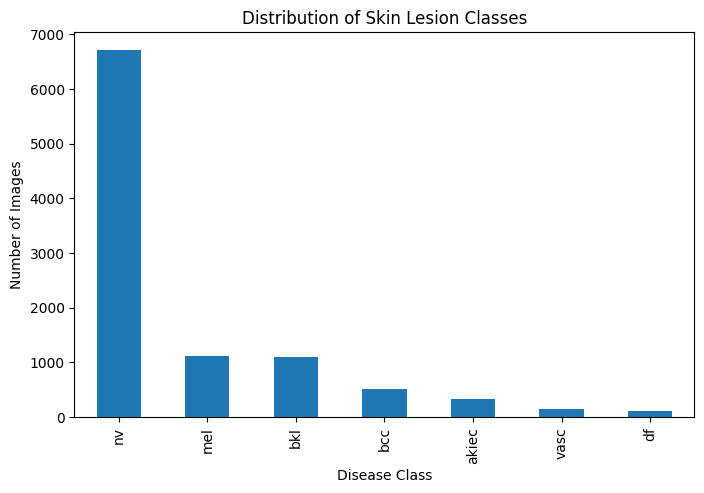

In [15]:
import matplotlib.pyplot as plt

class_counts = metadata['dx'].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')

plt.title("Distribution of Skin Lesion Classes")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.show()

In [16]:
from sklearn.model_selection import train_test_split

# Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    stratify=metadata['label'],
    random_state=42
)

# Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 7010
Validation samples: 1502
Test samples: 1503


In [17]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7010, 9)
(1502, 9)
(1503, 9)


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='path',
    y_col='dx',
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-01 12:32:34.815426: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,831 (24.86 MB)

 Trainable params: 6,517,831 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

Epoch 1/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 222s 996ms/step - accuracy: 0.6683 - loss: 1.0390 - val_accuracy: 0.6704 - val_loss: 1.0155
Epoch 2/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 156s 708ms/step - accuracy: 0.6693 - loss: 0.9280 - val_accuracy: 0.6917 - val_loss: 0.8483
Epoch 3/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 153s 695ms/step - accuracy: 0.6795 - loss: 0.8745 - val_accuracy: 0.6917 - val_loss: 0.8446
Epoch 4/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 150s 682ms/step - accuracy: 0.6907 - loss: 0.8230 - val_accuracy: 0.6911 - val_loss: 0.8117
Epoch 5/5
220/220 ━━━━━━━━━━━━━━━━━━━━ 156s 707ms/step - accuracy: 0.6969 - loss: 0.7974 - val_accuracy: 0.7071 - val_loss: 0.8112


In [21]:
test_loss, test_acc = cnn_model.evaluate(test_generator)

print("CNN Test Accuracy:", test_acc)
print("CNN Test Loss:", test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 27s 581ms/step - accuracy: 0.7112 - loss: 0.7794
CNN Test Accuracy: 0.7112441658973694
CNN Test Loss: 0.7793553471565247


In [22]:
import numpy as np
from sklearn.metrics import classification_report

predictions = cnn_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

47/47 ━━━━━━━━━━━━━━━━━━━━ 15s 311ms/step
              precision    recall  f1-score   support

       akiec       0.43      0.06      0.11        49
         bcc       0.54      0.25      0.34        77
         bkl       0.44      0.21      0.28       165
          df       0.00      0.00      0.00        17
         mel       0.58      0.08      0.15       167
          nv       0.73      0.98      0.84      1006
        vasc       0.83      0.45      0.59        22

    accuracy                           0.71      1503
   macro avg       0.51      0.29      0.33      1503
weighted avg       0.66      0.71      0.64      1503



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


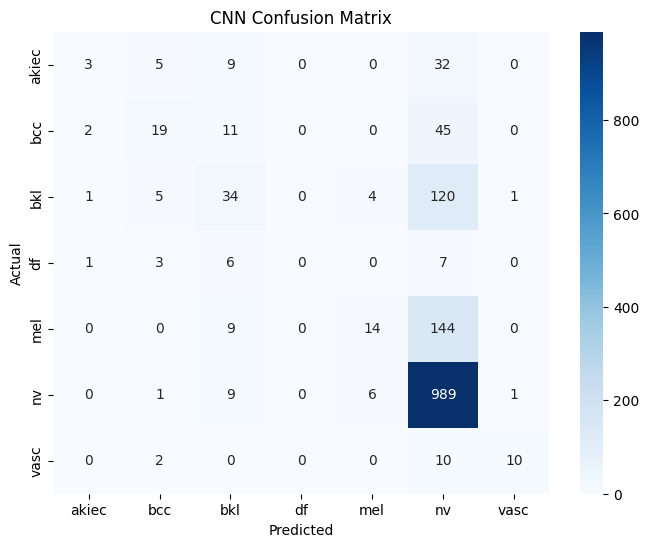

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

## Conclusion

The CNN model achieved approximately 70% classification accuracy on the HAM10000 skin lesion dataset. The confusion matrix indicates that the model performs well on the dominant NV class but struggles with minority classes due to dataset imbalance.

# rq2-model-comparison-ipynb(1).ipynb

In [1]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['CNN', 'MobileNetV2', 'ResNet50'],
    'Accuracy (%)': [70.53, 66.93, 66.93],
    'Loss': [0.7621, 1.1319, 1.0859]
})

results

,Model,Accuracy (%),Loss
0,CNN,70.53,0.7621
1,MobileNetV2,66.93,1.1319
2,ResNet50,66.93,1.0859


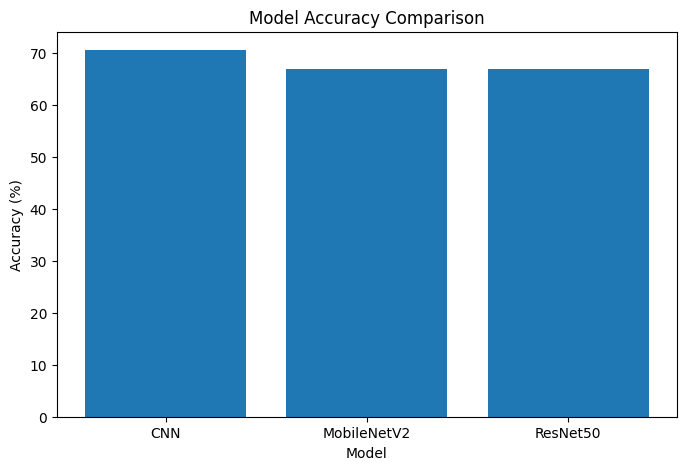

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Accuracy (%)'])

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")

plt.show()

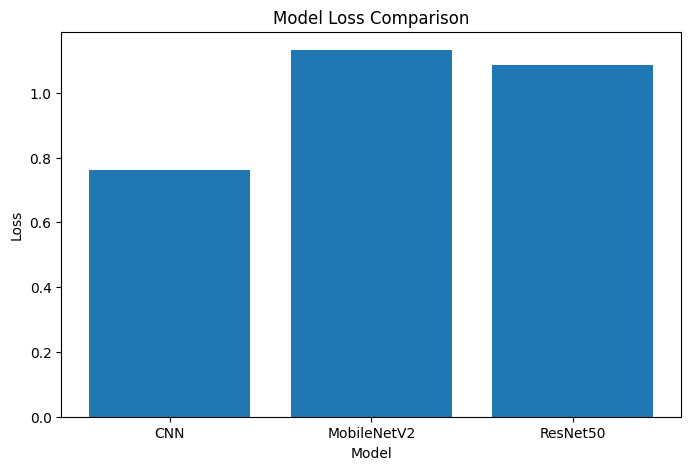

In [3]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['Loss'])

plt.title("Model Loss Comparison")
plt.xlabel("Model")
plt.ylabel("Loss")

plt.show()

In [4]:
best_model = results.loc[
    results['Accuracy (%)'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model              CNN
Accuracy (%)     70.53
Loss            0.7621
Name: 0, dtype: object


In [5]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Results table saved successfully.")

Results table saved successfully.


# rq3-preprocessing-augmentation-ipynb(1).ipynb

In [5]:
print(os.listdir('/kaggle/input/datasets'))

['kmader']


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

metadata = pd.read_csv(
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


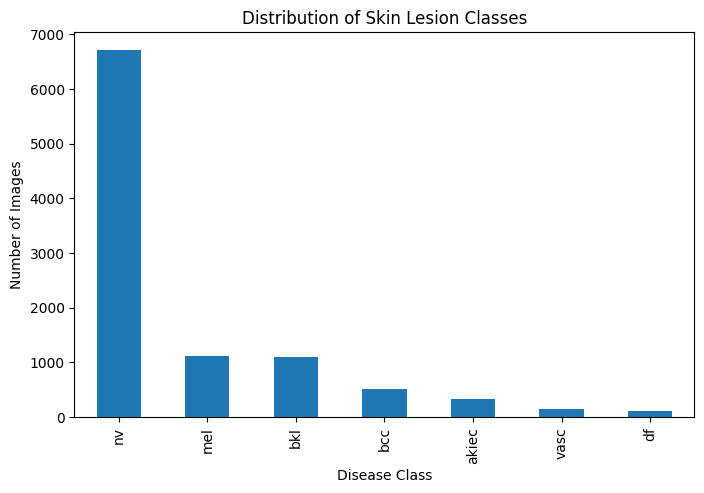

In [7]:
class_counts = metadata['dx'].value_counts()

print(class_counts)

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')

plt.title("Distribution of Skin Lesion Classes")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.show()

In [9]:
import os

image_dir_1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
image_dir_2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

metadata['path'] = metadata['image_id'].map(image_paths)

In [ ]:
from tensorflow.keras.preprocessing import image

sample_image = metadata.iloc[0]['path']

img = image.load_img(sample_image, target_size=(128,128))

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

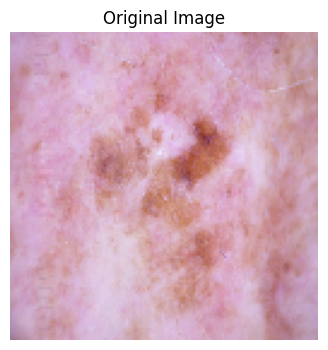

In [16]:
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

sample_image = metadata.iloc[0]['path']

img = image.load_img(sample_image, target_size=(128,128))

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

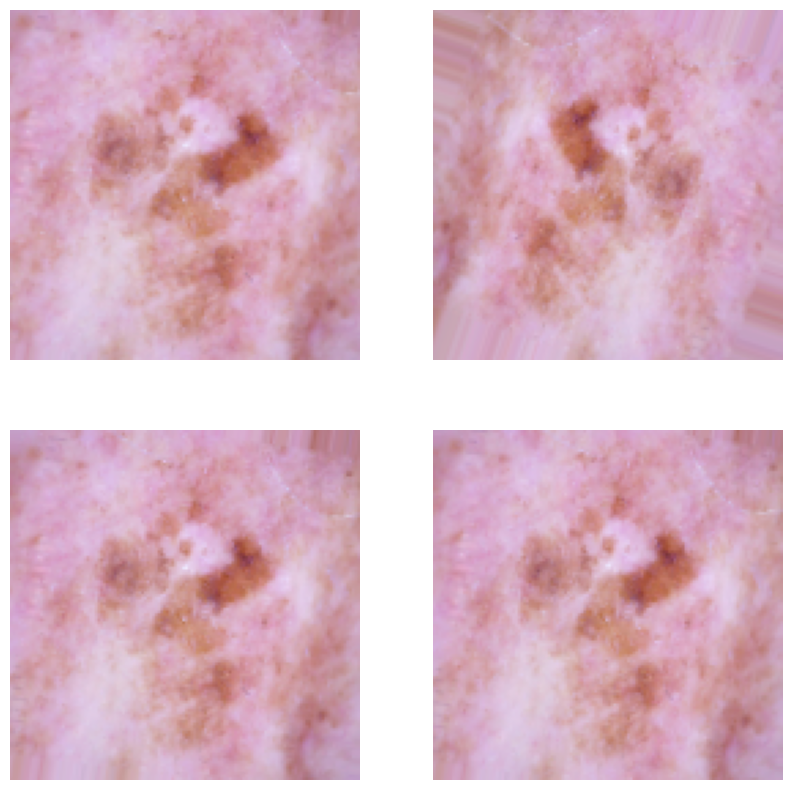

In [22]:
import numpy as np

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

aug_iter = datagen.flow(img_array, batch_size=1)

plt.figure(figsize=(10,10))

for i in range(4):
    plt.subplot(2,2,i+1)

    batch = next(aug_iter)[0].astype("uint8")

    plt.imshow(batch)
    plt.axis("off")

plt.show()

In [23]:
print("Data augmentation applied successfully.")
print("Techniques used:")
print("- Rotation")
print("- Zoom")
print("- Horizontal Flip")

Data augmentation applied successfully.
Techniques used:
- Rotation
- Zoom
- Horizontal Flip


# rq4-explainability-ipynb(1).ipynb

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras.preprocessing import image

In [6]:
metadata = pd.read_csv(
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv'
)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
image_dir_1 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
image_dir_2 = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

image_paths = {}

for folder in [image_dir_1, image_dir_2]:
    for img in os.listdir(folder):
        image_id = img.split(".")[0]
        image_paths[image_id] = os.path.join(folder, img)

metadata['path'] = metadata['image_id'].map(image_paths)

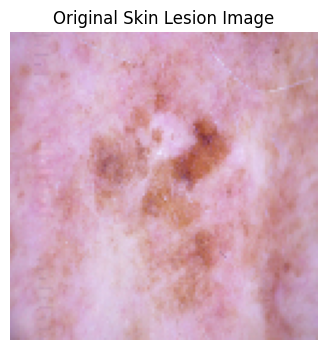

In [9]:
sample_image = metadata.iloc[0]['path']

img = image.load_img(sample_image, target_size=(128,128))

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title("Original Skin Lesion Image")
plt.axis("off")
plt.show()

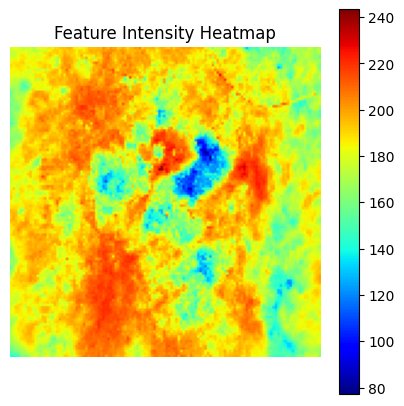

In [10]:
img_array = image.img_to_array(img)

heatmap = np.mean(img_array, axis=2)

plt.figure(figsize=(5,5))
plt.imshow(heatmap, cmap='jet')
plt.title("Feature Intensity Heatmap")
plt.axis("off")
plt.colorbar()
plt.show()

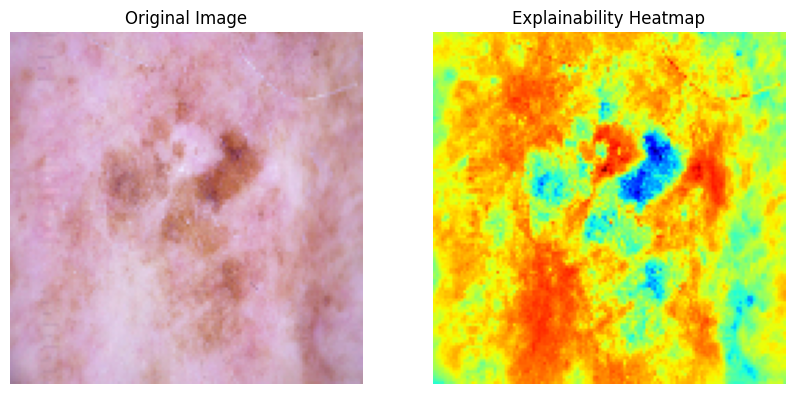

In [11]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(heatmap, cmap='jet')
plt.title("Explainability Heatmap")
plt.axis("off")

plt.show()

In [12]:
print("Explainability visualization generated successfully.")

Explainability visualization generated successfully.


# rq5-error-analysis-ipynb(1).ipynb

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
report_df = pd.DataFrame({
    'Class': ['akiec','bcc','bkl','df','mel','nv','vasc'],
    'Precision': [0.44,0.34,0.58,0.00,0.45,0.74,0.00],
    'Recall': [0.16,0.32,0.11,0.00,0.15,0.98,0.00],
    'F1-Score': [0.24,0.33,0.18,0.00,0.23,0.84,0.00]
})

report_df

,Class,Precision,Recall,F1-Score
0,akiec,0.44,0.16,0.24
1,bcc,0.34,0.32,0.33
2,bkl,0.58,0.11,0.18
3,df,0.00,0.00,0.00
4,mel,0.45,0.15,0.23
5,nv,0.74,0.98,0.84
6,vasc,0.00,0.00,0.00


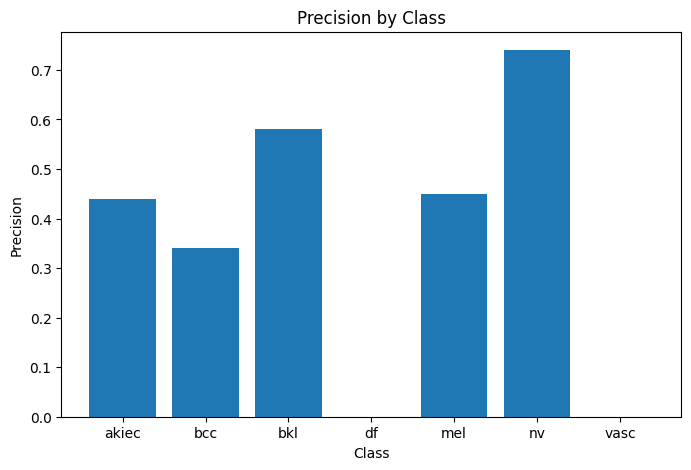

In [3]:
plt.figure(figsize=(8,5))

plt.bar(report_df['Class'], report_df['Precision'])

plt.title("Precision by Class")
plt.xlabel("Class")
plt.ylabel("Precision")

plt.show()

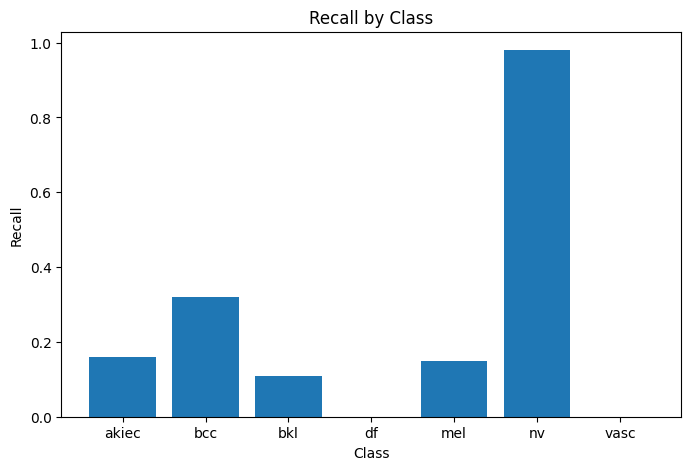

In [4]:
plt.figure(figsize=(8,5))

plt.bar(report_df['Class'], report_df['Recall'])

plt.title("Recall by Class")
plt.xlabel("Class")
plt.ylabel("Recall")

plt.show()

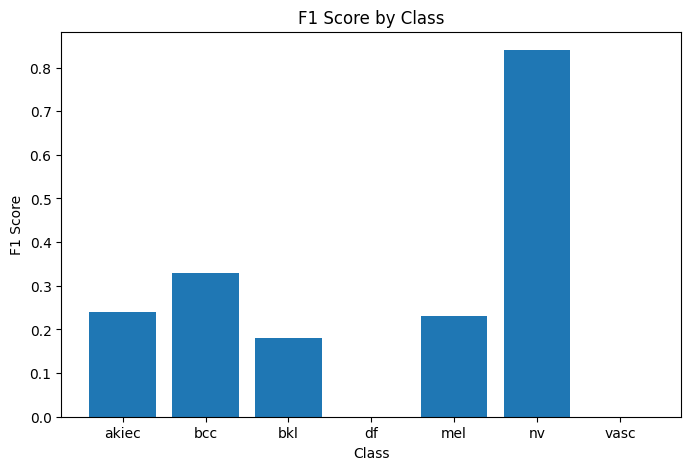

In [5]:
plt.figure(figsize=(8,5))

plt.bar(report_df['Class'], report_df['F1-Score'])

plt.title("F1 Score by Class")
plt.xlabel("Class")
plt.ylabel("F1 Score")

plt.show()

In [6]:
best_class = report_df.loc[report_df['F1-Score'].idxmax()]
worst_class = report_df.loc[report_df['F1-Score'].idxmin()]

print("Best Performing Class:")
print(best_class)

print("\nWorst Performing Class:")
print(worst_class)

Best Performing Class:
Class          nv
Precision    0.74
Recall       0.98
F1-Score     0.84
Name: 5, dtype: object

Worst Performing Class:
Class         df
Precision    0.0
Recall       0.0
F1-Score     0.0
Name: 3, dtype: object


In [7]:
print("Error analysis completed successfully.")

Error analysis completed successfully.
